# **EDA**

In [71]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# **Load Data**


In [72]:
dataset = pd.read_csv('diabetes.csv')
dataset.head() #Show 

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


# **Check Data**

Dataset Dimension, dalam kasus ini ada berapa baris dan brp kolom

In [73]:
# Dataset Dimension
# Ada 9 kolom dan 768 baris
dataset.shape

(768, 9)

Dataset typer atau tipe data dalam dataset

In [74]:
dataset.dtypes

Pregnancies                   int64
Glucose                       int64
BloodPressure                 int64
SkinThickness                 int64
Insulin                       int64
BMI                         float64
DiabetesPedigreeFunction    float64
Age                           int64
Outcome                       int64
dtype: object

In [75]:
dataset.describe().T

# Penjelasan :
# - .T itu transpose yang mksdny, menukar baris jdi kolom, dan kolom jadi baris
# - count ini itu kyak jumalah data, biasany sama dengan jumlah baris


# Dalam kasus ini:
# - Banyak missing value yang disamarkan menjadi 0
# - Perbedaan median dengan mean dan median terlalu jauh untuk kategori BMI ( Skewed dan outlier )
# - Standar Deviasi atau Std besar = data liat, Kategori Insulin, Std lebih besar dari mean yang artinya ini dataset berisik atau kotor

,count,mean,std,min,25%,50%,75%,max
Pregnancies,768.0,3.845052,3.369578,0.000,1.00000,3.0000,6.00000,17.00
Glucose,768.0,120.894531,31.972618,0.000,99.00000,117.0000,140.25000,199.00
BloodPressure,768.0,69.105469,19.355807,0.000,62.00000,72.0000,80.00000,122.00
SkinThickness,768.0,20.536458,15.952218,0.000,0.00000,23.0000,32.00000,99.00
Insulin,768.0,79.799479,115.244002,0.000,0.00000,30.5000,127.25000,846.00
BMI,768.0,31.992578,7.884160,0.000,27.30000,32.0000,36.60000,67.10
DiabetesPedigreeFunction,768.0,0.471876,0.331329,0.078,0.24375,0.3725,0.62625,2.42
Age,768.0,33.240885,11.760232,21.000,24.00000,29.0000,41.00000,81.00
Outcome,768.0,0.348958,0.476951,0.000,0.00000,0.0000,1.00000,1.00


In [76]:
# Ini ngecek data types percolumn sama memory usage

dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


# **Detect Missing Value**

In [77]:
np.round(dataset.isnull().mean() * 100, 1) #Deteksi Pertama sebelum di generalisasi

# Penjelasan, disini :
# - isnull(),digunakan untuk mencari missing value
# - * 100, ini untuk ubah hasil ke bentuk persentase

# Step di bawah ini adalah cara mengatasi missing valuenya

Pregnancies                 0.0
Glucose                     0.0
BloodPressure               0.0
SkinThickness               0.0
Insulin                     0.0
BMI                         0.0
DiabetesPedigreeFunction    0.0
Age                         0.0
Outcome                     0.0
dtype: float64

In [78]:
# 1

(dataset == 0).mean() * 100

Pregnancies                 14.453125
Glucose                      0.651042
BloodPressure                4.557292
SkinThickness               29.557292
Insulin                     48.697917
BMI                          1.432292
DiabetesPedigreeFunction     0.000000
Age                          0.000000
Outcome                     65.104167
dtype: float64

Penjelasan :
Nah disini keliatan ad berapa persen data yang hilang dari kategori" tersebut


In [79]:
# 2

# Pilih Kategori yang hanya punya persentase missing value
# Disini Pregnancies tidak dimasukkan karena, wajar jika seorang wanita tidak hamil atau memiliki riwayat kehamilan
category = ['Glucose' , 'BloodPressure' , 'SkinThickness' , 'Insulin' , 'BMI'] 

dataset[category] = dataset[category].replace(0, np.nan) # Mengganti value data 0 menjadi NaN

In [80]:
# 3
# Melakukan pengecekkan kembali setelah generalisasi
np.round(dataset.isnull().mean() * 100, 1)

Pregnancies                  0.0
Glucose                      0.7
BloodPressure                4.6
SkinThickness               29.6
Insulin                     48.7
BMI                          1.4
DiabetesPedigreeFunction     0.0
Age                          0.0
Outcome                      0.0
dtype: float64

In [81]:
# 4

dataset.fillna(dataset.median(), inplace = True) # Mengisi missing value dengan nilai median

# **Hitung categorical value, dan unique valuesny**

In [82]:
print(dataset['BMI'].value_counts()) # Disini 'BMI' bisa diganti sesuai nama kategor yang kalian mau

# Penjelasan :
# Buat ngitung value sih, jadi dari output di data cara bacany ya, nilai BMI 32.3 itu keluar sebanyak 14 kali, dst

BMI
32.3    14
32.0    13
31.6    12
31.2    12
33.3    10
        ..
22.7     1
45.4     1
24.9     1
42.0     1
46.3     1
Name: count, Length: 247, dtype: int64


In [83]:
print(dataset['BMI'].nunique()) # Ini buat 

# Penjelasan :
# Ini bakal ngeluarin jumalh value unique dalam data, sperti katgori BMI itu kn dari 768 data keluar 247

247


# **Make the graph**

**Make the Histogram for every category**

<function matplotlib.pyplot.show(close=None, block=None)>

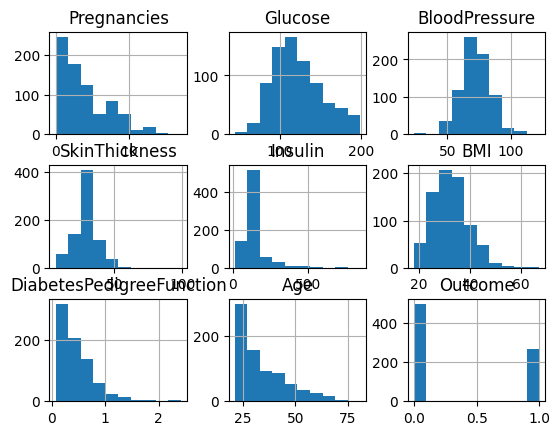

In [84]:
dataset.hist()
plt.tight_layout # Buat Biar rapih aj seh
plt.show

**KDE plot**

<function matplotlib.pyplot.show(close=None, block=None)>

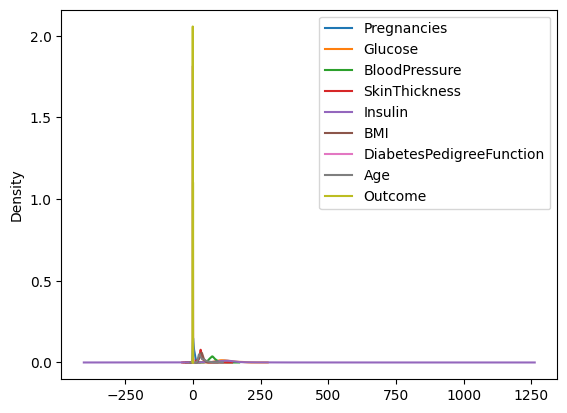

In [85]:
dataset.plot(kind='kde')
plt.tight_layout
plt.show

**Now with Boxplot**

<function matplotlib.pyplot.show(close=None, block=None)>

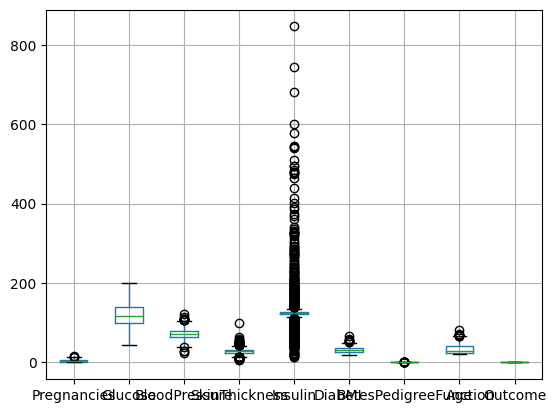

In [86]:
dataset.boxplot()
plt.tight_layout
plt.show

- ┌─────────────┐
- ──────┤ BOX ├──────
- └─────────────┘
- ↑ ↑ ↑ ↑ 
- Min Q1 Q2 Q3 Max
- (25%) (50%) (75%)
- IQR = Q3 - Q1
- Outlier if: x < Q1 - 1.5*IQR OR x > Q3 + 1.5*IQR
- Whiskers extend to last non-outlier value

Penjelasan :
- Dari ini kita bisa liat kl insulin agk ndk ngotak krn outlier parah
- Setiap Scale per kategori itu bias bgt karena perbedaan yang jauh

Maka dari itu ad step opsional buat bnerin, liat dibwah ini

In [87]:
# from sklearn.preprocessing import StandardScaler

# scaler = StandardScaler()
# x_scaled = scaler.fit_transform(X)

# # Log transform
# dataset['Insulin'] = np.log1p(dataset['Insulin'])

**Compare 3 Category**

<function matplotlib.pyplot.show(close=None, block=None)>

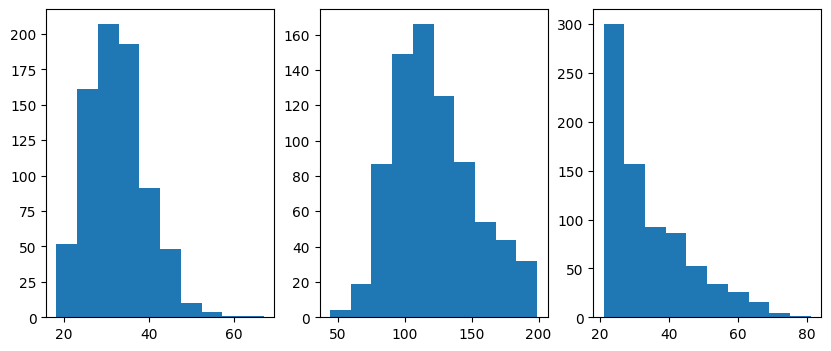

In [88]:
plt.figure(figsize=(10,4)) # Lebar 10, tinggi 4

# BMI
plt.subplot(1, 3, 1) # ambil posisi slot 1
plt.hist(dataset['BMI'])

# Glucose
plt.subplot(1, 3, 2) # ambil posisi slot 2
plt.hist(dataset['Glucose'])

# Age
plt.subplot(1, 3, 3) # ambil posisi slot 3
plt.hist(dataset['Age'])

plt.show

**Note**
- Figsize itu dipake buat bandingin 2 atau lebih untuk data histogram atau histogram per kategori

 # **Bivariate Analysis**

**Correlation**

- Korelasi linear antar 2 variabel
- 1 = Hubunagn kuat ; 0 = ngk ad hubungan ; -1 = berlawanan


In [89]:
corr_matrix = dataset.corr()
print(corr_matrix)

                          Pregnancies   Glucose  BloodPressure  SkinThickness  \
Pregnancies                  1.000000  0.128213       0.208615       0.081770   
Glucose                      0.128213  1.000000       0.218937       0.192615   
BloodPressure                0.208615  0.218937       1.000000       0.191892   
SkinThickness                0.081770  0.192615       0.191892       1.000000   
Insulin                      0.025047  0.419451       0.045363       0.155610   
BMI                          0.021559  0.231049       0.281257       0.543205   
DiabetesPedigreeFunction    -0.033523  0.137327      -0.002378       0.102188   
Age                          0.544341  0.266909       0.324915       0.126107   
Outcome                      0.221898  0.492782       0.165723       0.214873   

                           Insulin       BMI  DiabetesPedigreeFunction  \
Pregnancies               0.025047  0.021559                 -0.033523   
Glucose                   0.419451  0.231

**Penjelasan :**

- Disini kalian liat, perbandingan kategori ke outcome, dimana cara liatnya ?
- Kalian liat korelasi Glucose dengan outcome itu yang paling gede kan, artinya Glucose tinggi pengaruh ke diabetes
- Ada lagi BMI, ngaruh jg, walaupun ngga tinggi tpi ttep ada pengaruh yang gk kecil juga
- Dan korelasi terlemah ya mungkin ada di BloodPressure, Insulin, dll

**Penilaian :**
- High > 0.4
- Medium 0.2 - 0.4
- Low < 0.2

**Note :**
- Disini ada yang bisa bikin mmodel kita rusak, yaitu terutama SkinTickness dengan BMI yang lumayan tinggi yang artinya fitur saling **redundant** atau bawa data yang isinya mirip


**Visualisasi Correlation Matrix**

<function matplotlib.pyplot.show(close=None, block=None)>

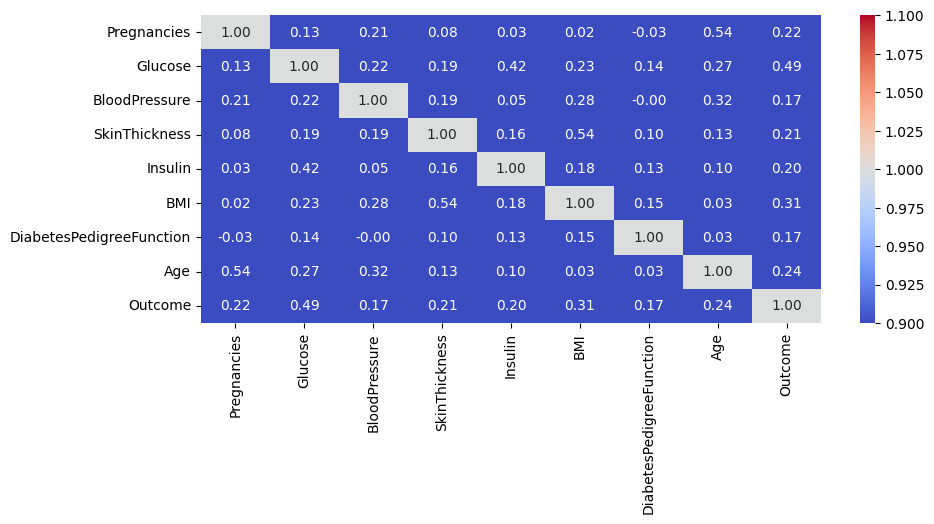

In [90]:
plt.figure(figsize = (10, 4))
sns.heatmap(
    corr_matrix,
    annot = True, # Tampilin angka
    fmt = '.2f', # 2 angka blkg koma
    cmap = 'coolwarm', # Blue = positive, Blue = Negative ( Secara Konsep Normal )
    vmin = 1, vmax = 1
)

plt.show

**Penjelasan :**
- Dari dataset itu kn ngga ad korelasi negatif, hanya ada korelasi positif dengan nilai terkecil itu -0,01
- Jadi warna biru dsni bukan negatif tetapi positif kecil, juga karena nilai plot itu 0,9 -> 1.1 yang artinya hampir semua positif sih

**Note :**
- Sejujurny ini malah slh ( GPT ), karena range data cmn sekitar -0.01 sampai 1
- Color scale juga ke compress bro di 0.9 - 1.1
- Hasilnya warna ndak sesuai konsep umum dan salah interpretasi

**Solusi :**
- Buat ulang lah bro di bwah nih


<function matplotlib.pyplot.show(close=None, block=None)>

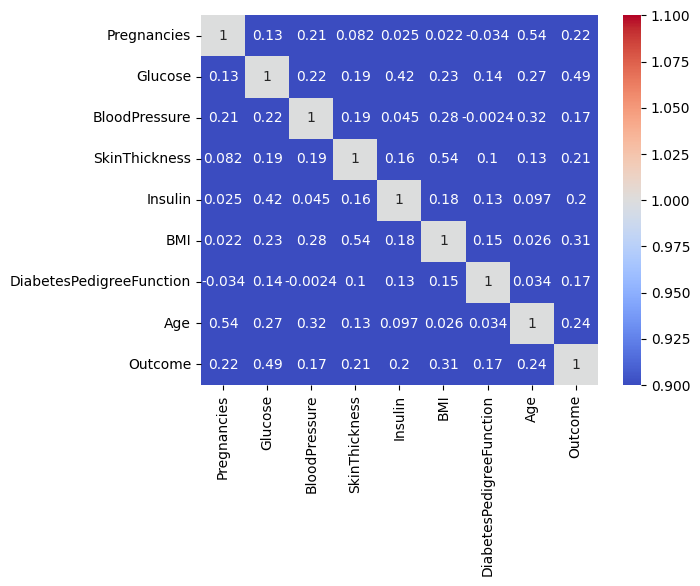

In [91]:
sns.heatmap(
    dataset.corr(),
    annot = True,
    cmap = 'coolwarm',
    vmin = 1, vmax = 1
)

plt.show

**Penjelasan :**
- Masih keliatan biru sih emang, tp ndk separh tdi
- korelasi ini di range 0.1 - 0.5
- Dalam skala -1 sampe 1 itu lemah sampe sedang
- Terlihat mirip tpi ternyata beda

**Note :**
- Glucose ttep strongest signal sih, disusul BMI
- Kl pake Logistic REgression pasti salah karena korelasi Pregnancies ke BMI itu ngk wajar, informasi dialamny terlalu overlap sih

**Scater Plot**

<function matplotlib.pyplot.show(close=None, block=None)>

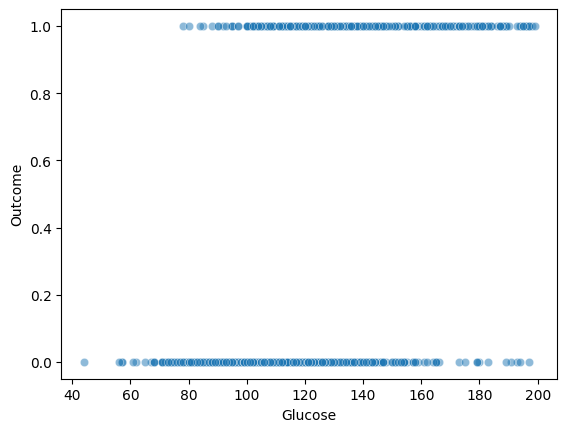

In [92]:
sns.scatterplot(x='Glucose', y='Outcome', data=dataset, alpha=0.5)
plt.show

**Note :**
- Kurang cocok krn numpuk tuh di 0 dgn 1, meding bloxplot

**Pair Plot**

<function matplotlib.pyplot.show(close=None, block=None)>

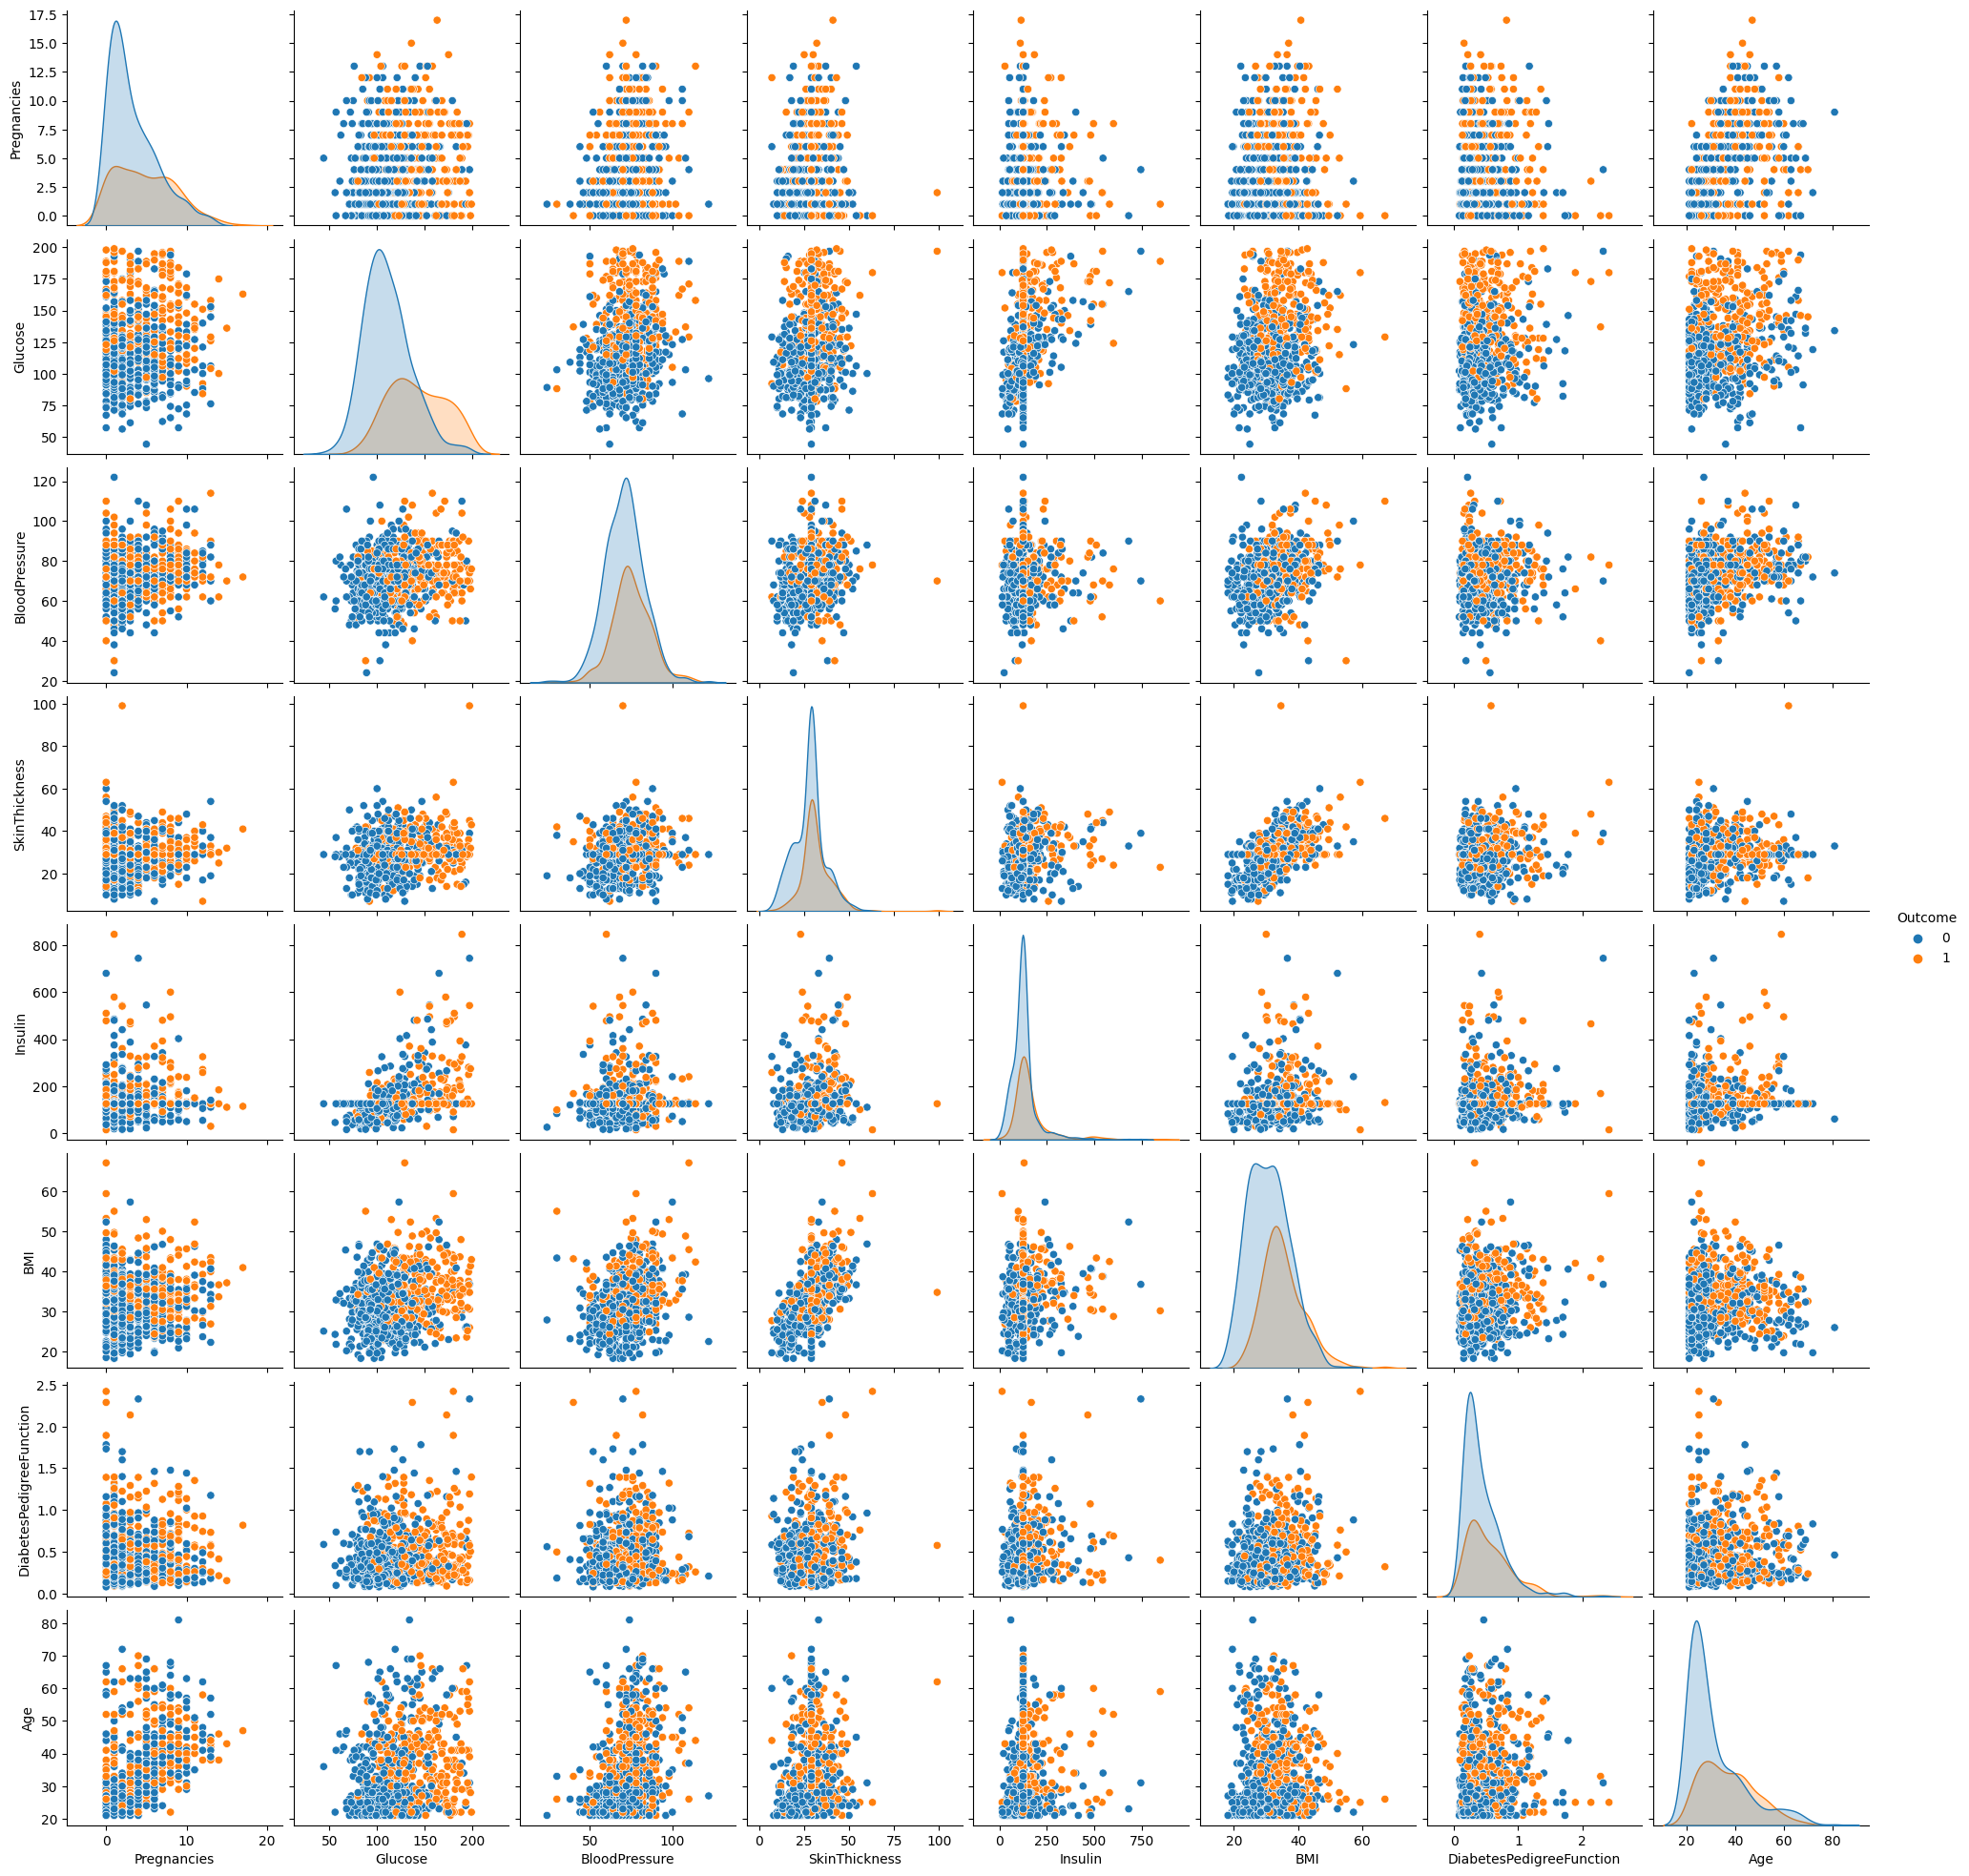

In [93]:
sns.pairplot(dataset, hue = 'Outcome')
plt.show

**Box Plot**


<function matplotlib.pyplot.show(close=None, block=None)>

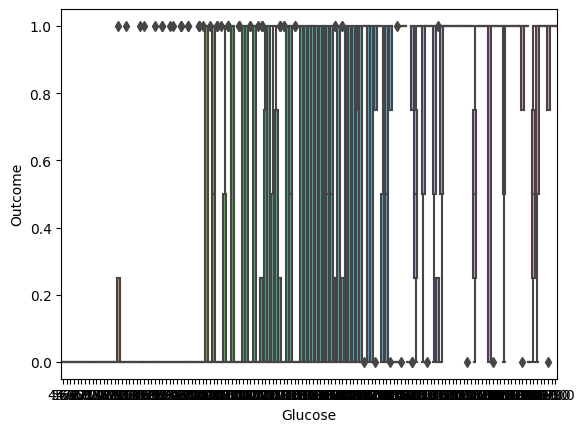

In [94]:
sns.boxplot(x = 'Glucose' , y = 'Outcome', data = dataset)
plt.show

**Violin PLot ( Gabungan Boxplot + KDE)**

<function matplotlib.pyplot.show(close=None, block=None)>

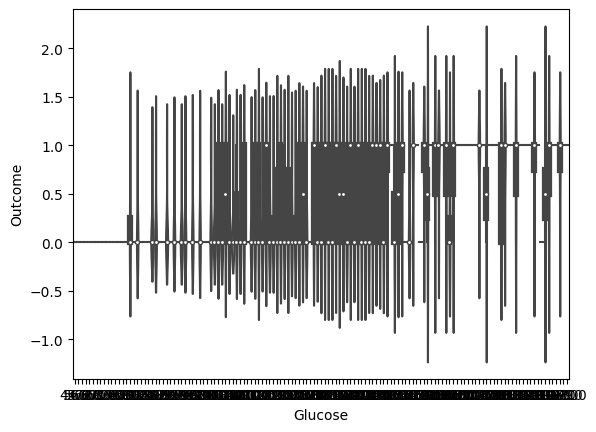

In [95]:
sns.violinplot(x = 'Glucose' , y = 'Outcome', data = dataset)
plt.show

**Notes**
| Data                       | Plot             |
| -------------------------- | ---------------- |
| continuous vs continuous   | scatter          |
| categorical vs continuous  | boxplot / violin |
| categorical vs categorical | countplot        |


# **Outlier Detection**

**Method IQR ( Interquartile Range )** 

In [96]:
q1 = dataset['Glucose'].quantile(0.25) # 25% Data
q3 = dataset['Glucose'].quantile(0.75) # 75% Data
IQR =  q3 - q1 # Rentang tengah data

lower_fence = q1 - 1.5 * IQR
upper_fence = q3 + 1.5 * IQR

outliers = dataset[(dataset['Glucose'] < lower_fence) | (dataset['Glucose'] > upper_fence)]
print(f"Found {len(outliers)} outliers")

Found 0 outliers


**Z-Score Method**

In [97]:
from scipy import stats

z_scores = np.abs(stats.zscore(dataset['Glucose']))
outlier_z = dataset[ z_scores > 3 ] # lbih dri 3 std dri mean
print(f"Z-Score outlier : {len(outlier_z)}")



Z-Score outlier : 0


**Cara ngehandle Outlier**

In [98]:
dataset_clean = dataset[( z_scores <= 3 )] # remove data oulier dibwahny

# **Advanced EDA**

In [99]:
print(dataset.groupby('Glucose')['Outcome'].agg(['mean', 'std' , 'count'])) 
# ngegrup statistik antar 2 var ini based on mean, standar deviasi, dan count

         mean  std  count
Glucose                  
44.0     0.00  NaN      1
56.0     0.00  NaN      1
57.0     0.00  0.0      2
61.0     0.00  NaN      1
62.0     0.00  NaN      1
...       ...  ...    ...
195.0    1.00  0.0      2
196.0    1.00  0.0      3
197.0    0.75  0.5      4
198.0    1.00  NaN      1
199.0    1.00  NaN      1

[135 rows x 3 columns]


In [100]:
pd.crosstab(dataset['Glucose'], dataset['Outcome'], normalize='index')
# buat tabel distribusi Outcome untuk setiap nilai Glucose, dalam bentuk proporsi

Outcome,0,1
Glucose,,
44.0,1.00,0.00
56.0,1.00,0.00
57.0,1.00,0.00
61.0,1.00,0.00
62.0,1.00,0.00
...,...,...
195.0,0.00,1.00
196.0,0.00,1.00
197.0,0.25,0.75


**Penjelasan :**
- Hasil seperti Glucose = 44 → 100% non-diabetes tidak bisa dijadikan kesimpulan karena kemungkinan besar hanya berasal dari sangat sedikit sampel (misalnya 1 atau 2 data saja), sehingga proporsi itu tidak stabil secara statistik dan sangat mudah berubah jika ada tambahan data; ini disebut high variance / unreliable estimate, di mana nilai ekstrem muncul bukan karena pola nyata, tapi karena kebetulan dari data kecil, sehingga tidak bisa digeneralisasi ke populasi yang lebih luas.

**Pivot Table**


In [101]:
dataset.pivot_table(
    values = 'Glucose',
    index = 'Outcome',
    aggfunc = 'mean'
)
# Pivot ini buat ringkas data aj
#kl ini buat rata" Glucose non-diabetes VS Glucose diabetes

,Glucose
Outcome,
0,110.682000
1,142.130597


In [102]:
dataset.pivot_table(
    values='BMI', 
    index='Outcome', 
    aggfunc='mean'
)

# Kl ini BMI per Outcome

,BMI
Outcome,
0,30.885600
1,35.383582


Violin Plot tdi kn dh ad


**FacetGrid ( Separate plots by group )**

In [103]:
dataset['Glucose_bin'] = pd.cut(dataset['Glucose'], bins=4)

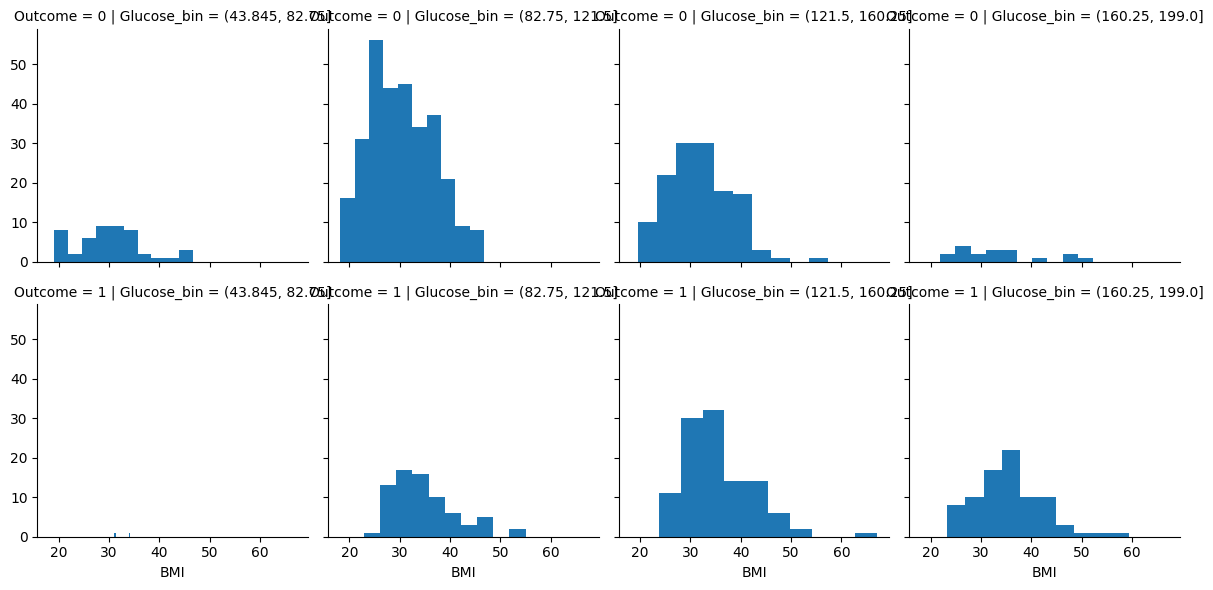

In [104]:
g = sns.FacetGrid(dataset, col='Glucose_bin', row='Outcome')
g.map(plt.hist, 'BMI')
plt.show()

**Notes :**
- Bin atau binning itu ubah data kontinu jdi data kategorical, ini penting biar ngga berantakan atau bertabrakan seh

- trus buat graphic yg Glucose dgn Outcome, aslinya bisa diganti kyak BMI dgn Outcome, tergantung korelasi sih

In [105]:
df = dataset
df.to_csv('data/cleaned_data.csv', index=False)